# Affine Transformation via Matrix Application
# Segment 2: Eigendecomposition
# Affine Transformation via Matrix Application

In [1]:
import numpy as np
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# lets say we have a vector v:
v = np.array([3,1])
v

array([3, 1])

Let's plot $v$ using my `plot_vectors()` function (which is based on Hadrien Jean's `plotVectors()` function from [this notebook](this notebook), under [MIT license](MIT license)).

In [3]:
def plot_vectors(vectors, colors):
    """
    Plot one or more vectors in a 2D plane, specifying a color for each. 

    Arguments
    ---------
    vectors: list of lists or of arrays
        Coordinates of the vectors to plot. For example, [[1, 3], [2, 2]] 
        contains two vectors to plot, [1, 3] and [2, 2].
    colors: list
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.
        
    Example
    -------
    plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    """
    plt.figure()
    plt.axvline(x = 0, color = "lightgray")
    plt.axhline(y = 0, color = "lightgray")

    for i in range(len(vectors)):
        x = np.concatenate([[0,0], vectors[i]])
        plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=colors[i],)
        print(vectors[i])
        print(x)

[3 1]
[0 0 3 1]


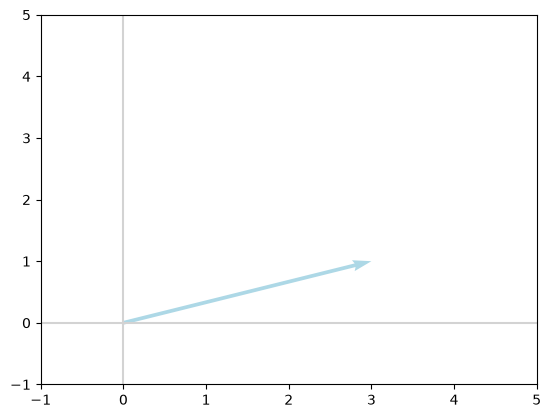

In [4]:
plot_vectors([v], ['lightblue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

"Applying" a matrix to a vector (i.e., performing matrix-vector multiplication) can linearly transform the vector, e.g, rotate it or rescale it.

The identity matrix, introduced earlier, is the exception that proves the rule: Applying an identity matrix does not transform the vector:

In [5]:
I = np.array([[1,0],
             [0,1]])
I

array([[1, 0],
       [0, 1]])

In [6]:
v

array([3, 1])

In [7]:
Iv = np.dot(I,v)
Iv

array([3, 1])

In [8]:
v == Iv

array([ True,  True])

[3 1]
[0 0 3 1]


(-1.0, 5.0)

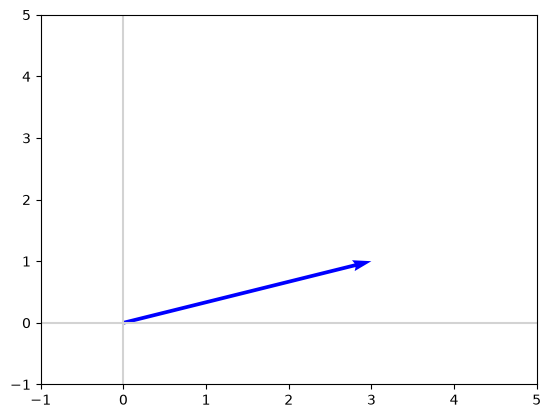

In [9]:
plot_vectors([Iv], ["blue"])
plt.xlim(-1,5)
plt.ylim(-1,5)

In contrast, consider this matrix (let's call it E) that flips vectors over the x-axis:

In [10]:
E = np.array([[1,0],
             [0,-1]])
E

array([[ 1,  0],
       [ 0, -1]])

In [11]:
v

array([3, 1])

In [12]:
Ev = np.dot(E,v)
Ev

array([ 3, -1])

[3 1]
[0 0 3 1]
[ 3 -1]
[ 0  0  3 -1]


(-3.0, 3.0)

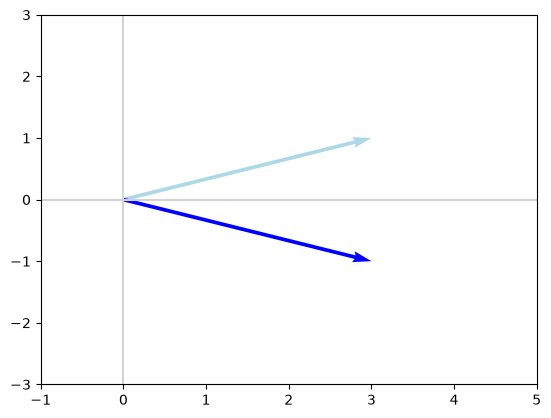

In [13]:
plot_vectors([v, Ev], ['lightblue', 'blue'])
plt.xlim(-1, 5)
plt.ylim(-3, 3)

Or, this matrix, F, which flips vectors over the y-axis:

In [14]:
F = np.array([[-1,0], [0,1]])
F

array([[-1,  0],
       [ 0,  1]])

In [15]:
v

array([3, 1])

In [16]:
Fv = np.dot(F,v)
Fv

array([-3,  1])

[3 1]
[0 0 3 1]
[-3  1]
[ 0  0 -3  1]


(-3.0, 5.0)

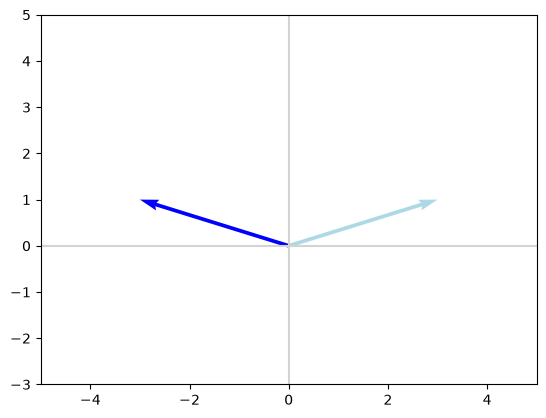

In [17]:
plot_vectors([v, Fv], ['lightblue', 'blue'])
plt.xlim(-5,5)
plt.ylim(-3,5)

Applying a flipping matrix is an example of an **affine transformation**: a change in geometry that may adjust distances or angles between vectors, but preserves parallelism between them.

In addition to flipping a matrix over an axis (a.k.a., *reflection*), other common affine transformations include:

* *Scaling* (changing the length of vectors)
* *Shearing* (example of this on the Mona Lisa coming up shortly)
* *Rotation*

(See [here](https://stackabuse.com/affine-image-transformations-in-python-with-numpy-pillow-and-opencv/) for an outstanding blog post on affine transformations in Python, including how to apply them to images as well as vectors.)

A single matrix can apply multiple affine transforms simultaneously (e.g., flip over an axis and rotate 45 degrees). As an example, let's see what happens when we apply this matrix $A$ to the vector $v$:

In [18]:
A = np.array([[-1,4],
             [2,-2]])
A

array([[-1,  4],
       [ 2, -2]])

In [19]:
v

array([3, 1])

In [20]:
Av = np.dot(A,v)
Av

array([1, 4])

[3 1]
[0 0 3 1]
[1 4]
[0 0 1 4]


(-1.0, 5.0)

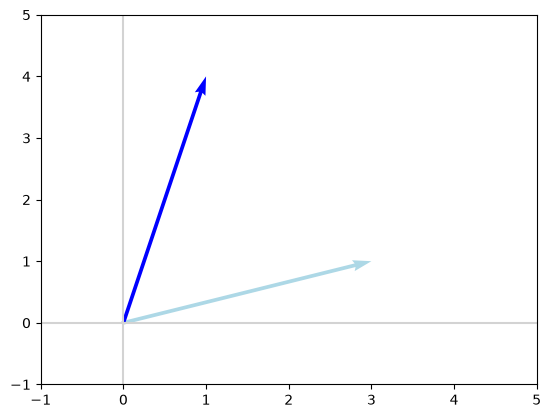

In [21]:
plot_vectors([v, Av], ["lightblue", "blue"])
plt.xlim(-1,5)
plt.ylim(-1,5)

[2 1]
[0 0 2 1]
[2 2]
[0 0 2 2]


(-1.0, 5.0)

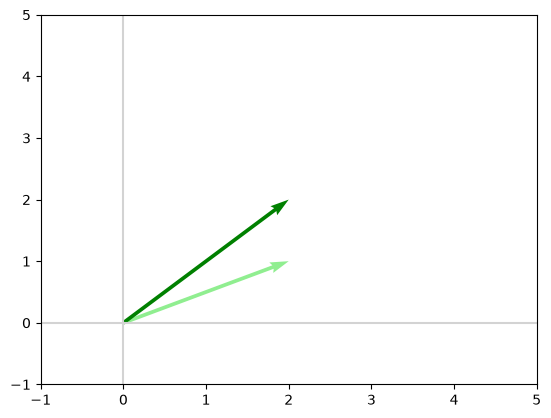

In [22]:
# Another example of  applying A:
v2 = np.array([2,1])
plot_vectors([v2,np.dot(A,v2)], ["lightgreen", "green"])
plt.xlim(-1,5)
plt.ylim(-1,5)

We can concatenate several vectors together into a matrix (say, $V$), where each column is a separate vector. Then, whatever linear transformations we apply to $V$ will be independently applied to each column (vector):

In [23]:
v

array([3, 1])

In [24]:
# recall that we need to convert array to 2D to transpose into column, e.g.:
np.matrix(v).T

matrix([[3],
        [1]])

In [25]:
v2

array([2, 1])

In [26]:
v3 = np.array([-3, -1]) # mirror image of v over both axes
v4 = np.array([-1, 1])

[3 1]
[0 0 3 1]
[-3 -1]
[ 0  0 -3 -1]


(-5.0, 5.0)

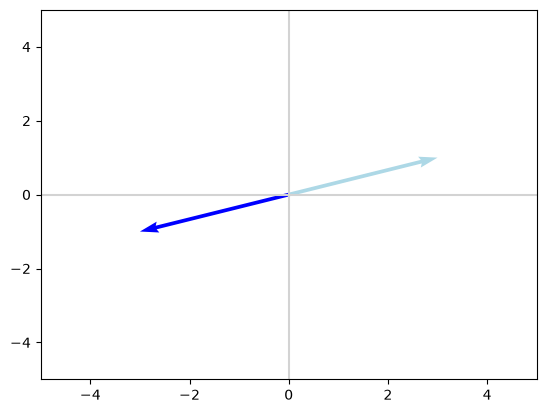

In [27]:
plot_vectors([v,v3], ["lightblue", "blue"])
plt.xlim(-5,5)
plt.ylim(-5,5)

In [28]:
V = np.concatenate((np.matrix(v).T,
                   np.matrix(v2).T,
                   np.matrix(v3).T,
                   np.matrix(v4).T), axis = 1)
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [29]:
# V = np.concatenate((np.matrix(v).T,
#                    np.matrix(v2).T,
#                    np.matrix(v3).T,
#                    np.matrix(v4).T), axis = 1)
# V

In [30]:
A

array([[-1,  4],
       [ 2, -2]])

In [31]:
I

array([[1, 0],
       [0, 1]])

In [32]:
I.shape

(2, 2)

In [33]:
A.shape

(2, 2)

In [34]:
V.shape

(2, 4)

In [35]:
IV = np.dot(I,V)
IV

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [36]:
AV = np.dot(A,V)
AV

matrix([[ 1,  2, -1,  5],
        [ 4,  2, -4, -4]])

In [37]:
# function to convert column of matrix to 1D vector: 
def vectorfy(mtrx, clmn):
    return np.array(mtrx[:,clmn]).reshape(-1)

In [38]:
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [39]:
vectorfy(V,0)


array([3, 1])

In [40]:
vectorfy(V, 0) == v

array([ True,  True])

[3 1]
[0 0 3 1]
[2 1]
[0 0 2 1]
[-3 -1]
[ 0  0 -3 -1]
[-1  1]
[ 0  0 -1  1]
[1 4]
[0 0 1 4]
[2 2]
[0 0 2 2]
[-1 -4]
[ 0  0 -1 -4]
[ 5 -4]
[ 0  0  5 -4]


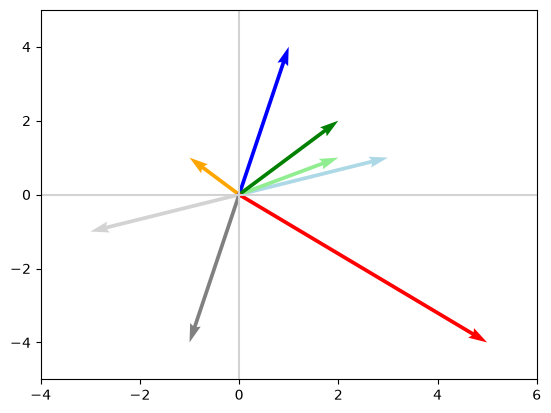

In [41]:
plot_vectors([vectorfy(V, 0), vectorfy(V, 1), vectorfy(V, 2), vectorfy(V, 3),
             vectorfy(AV, 0), vectorfy(AV, 1), vectorfy(AV, 2), vectorfy(AV, 3)], 
            ['lightblue', 'lightgreen', 'lightgray', 'orange',
             'blue', 'green', 'gray', 'red'])
plt.xlim(-4, 6)
_ = plt.ylim(-5, 5)

### Eigenvectors and Eigenvalues

An **eigenvector** (*eigen* is German for "typical"; we could translate *eigenvector* to "characteristic vector") is a special vector $v$ such that when it is transformed by some matrix (let's say $A$), the product $Av$ has the exact same direction as $v$.[cite: 5]

An **eigenvalue** is a scalar (traditionally represented as $\lambda$) that simply scales the eigenvector $v$ such that the following equation is satisfied:[cite: 5]

$$Av = \lambda v$$

Easiest way to understand this is to work through an example:[cite: 5]



In [42]:
A

array([[-1,  4],
       [ 2, -2]])

Eigenvectors and eigenvalues can be derived algebraically (e.g., with the (QR algorithm), which was independently developed in the 1950s by both (Vera Kublanovskaya) and John Francis), however this is outside scope of the *ML Foundations* series. We'll cheat with NumPy `eig()` method, which returns a tuple of:

* a vector of eigenvalues
* a matrix of eigenvectors



In [43]:
lambdas, V = np.linalg.eig(A)

The matrix contains as many eigenvectors as there are columns of A:

In [44]:
V= V.real
V

array([[ 0.86011126, -0.76454754],
       [ 0.51010647,  0.64456735]])

With a corresponding eigenvalue for each eigenvector:

In [45]:
lambdas

array([ 1.37228132+0.j, -4.37228132+0.j])

Let's confirm that $Av = \lambda v$ for the first eigenvector:

In [46]:
v = V[:,0]
v

array([0.86011126, 0.51010647])

In [47]:
lambduh = np.real(lambdas[0])
float(lambduh)

1.3722813232690143

In [48]:
A

array([[-1,  4],
       [ 2, -2]])

In [49]:
Av = np.dot(A,v)
Av

array([1.18031462, 0.70000958])

In [50]:
lambduh * v

array([1.18031462, 0.70000958])

[1.18031462 0.70000958]
[0.         0.         1.18031462 0.70000958]
[0.86011126 0.51010647]
[0.         0.         0.86011126 0.51010647]


(-1.0, 2.0)

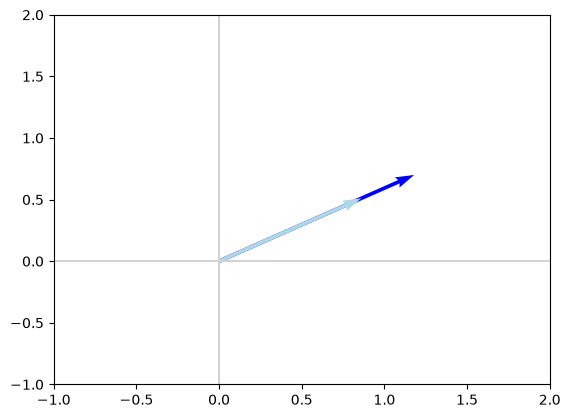

In [51]:
plot_vectors([Av,v], ["blue", "lightblue"])
plt.xlim(-1,2)
plt.ylim(-1,2)

And again for the second eigenvector of A:

In [52]:
v2 = V[:,1]
v2

array([-0.76454754,  0.64456735])

Av = lambda v

In [53]:
Av2 = np.dot(A,v2)
Av2

array([ 3.34281692, -2.81822977])

In [54]:
lamduh_2 = lambdas[1]
float(lamduh_2.real)

-4.372281323269014

In [55]:
np.real(lamduh_2*v2)

array([ 3.34281692, -2.81822977])

[1.18031462 0.70000958]
[0.         0.         1.18031462 0.70000958]
[0.86011126 0.51010647]
[0.         0.         0.86011126 0.51010647]
[ 3.34281692 -2.81822977]
[ 0.          0.          3.34281692 -2.81822977]
[-0.76454754  0.64456735]
[ 0.          0.         -0.76454754  0.64456735]


(-3.0, 2.0)

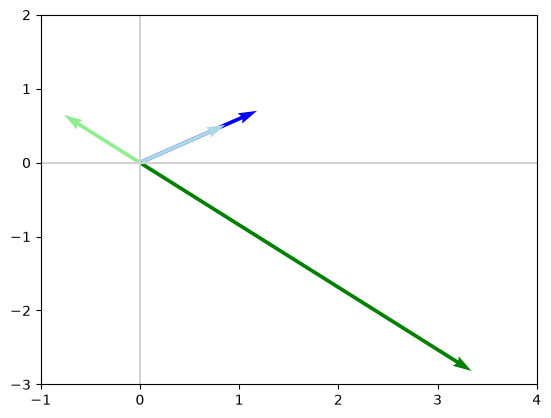

In [56]:
plot_vectors([Av, v, Av2, v2],
            ["blue", "lightblue", "green", "lightgreen"])
plt.xlim(-1, 4)
plt.ylim(-3, 2)

Using the PyTorch eig() method, we can do exactly the same:

In [57]:
A

array([[-1,  4],
       [ 2, -2]])

In [58]:
A_p = torch.tensor([[-1,4],
                   [2,-2]],dtype = torch.float32)
A_p

tensor([[-1.,  4.],
        [ 2., -2.]])

In [59]:
lambdas_cplx, V_cplx = torch.linalg.eig(A_p)# outputs complex numbers because real matrices can have complex eigenvectors


In [60]:
V_cplx # complex-typed values with "0.j" imaginary part are in fact real numbers

tensor([[ 0.8601+0.j, -0.7645+0.j],
        [ 0.5101+0.j,  0.6446+0.j]])

In [61]:
V_p = V_cplx.float()
V_p

C:\Users\Diwas\AppData\Local\Temp\ipykernel_10352\1096125134.py:1: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  V_p = V_cplx.float()


tensor([[ 0.8601, -0.7645],
        [ 0.5101,  0.6446]])

In [62]:
lambdas_cplx


tensor([ 1.3723+0.j, -4.3723+0.j])

In [63]:
lambdas_p = lambdas_cplx.float()
lambdas_p

tensor([ 1.3723, -4.3723])

In [64]:
vp = V_p[:,0]
vp

tensor([0.8601, 0.5101])

In [65]:
lambda_p = lambdas_p[0]
lambda_p

tensor(1.3723)

In [66]:
Av_p = torch.matmul(A_p, vp)
Av_p

tensor([1.1803, 0.7000])

In [67]:
lambda_p * vp

tensor([1.1803, 0.7000])

In [68]:
v2_p = V_p[:,1]
v2_p

tensor([-0.7645,  0.6446])

In [69]:
lambda2_p = lambdas_p[1]
lambda2_p

tensor(-4.3723)

In [70]:
Av2_p = torch.matmul(A_p, v2_p)
Av2_p

tensor([ 3.3428, -2.8182])

In [71]:
lambda2_p * v2_p

tensor([ 3.3428, -2.8182])

[1.1803145 0.7000096]
[0.         0.         1.18031454 0.70000958]
[0.86011124 0.51010644]
[0.         0.         0.86011124 0.51010644]
[ 3.3428168 -2.8182297]
[ 0.          0.          3.34281683 -2.81822968]
[-0.7645475  0.6445673]
[ 0.          0.         -0.76454753  0.64456731]


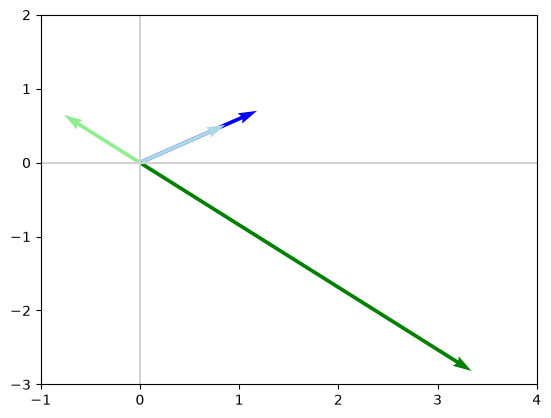

In [72]:
plot_vectors([Av_p.numpy(), vp.numpy(), Av2_p.numpy(), v2_p.numpy()], 
            ['blue', 'lightblue', 'green', 'lightgreen'])
plt.xlim(-1, 4)
_ = plt.ylim(-3, 2)

# Eigenvectors in >2 Dimensions

While plotting gets trickier in higher-dimensional spaces, we can nevertheless find and use eigenvectors with more than two dimensions. Here's a 3D example (there are three dimensions handled over three rows):

In [73]:
X = np.array([[25,2,9],
             [5,26,-5],
             [3,7,-1]])
X

array([[25,  2,  9],
       [ 5, 26, -5],
       [ 3,  7, -1]])

In [74]:
lambdas_X, V_X = np.linalg.eig(X)

In [75]:
lambdas_X = lambdas_X.real.astype(float)
lambdas_X

array([29.67623202, 20.62117365, -0.29740567])

In [76]:
V_X=V_X.real.astype(float)
V_X

array([[-0.71175736, -0.6501921 , -0.34220476],
       [-0.66652125,  0.74464056,  0.23789717],
       [-0.22170001,  0.15086635,  0.90901091]])

In [77]:
v_x = V_X[:,0]
v_x

array([-0.71175736, -0.66652125, -0.22170001])

In [78]:
v2_x = V_X[:,1]
v2_x

array([-0.6501921 ,  0.74464056,  0.15086635])

In [79]:
lambda_x = lambdas_X[0] 
lambda_x

np.float64(29.676232023948902)

In [80]:
lambda_x2 = lambdas_X[1]
lambda_x2

np.float64(20.62117365053535)

In [81]:
Xv1 = np.dot(X,v_x)
Xv1

array([-21.12227645, -19.77983919,  -6.5792208 ])

In [82]:
lambda_x * v_x

array([-21.12227645, -19.77983919,  -6.5792208 ])

In [83]:
Xv2 = np.dot(X,v2_x)
Xv2

array([-13.40772428,  15.3553624 ,   3.11104129])

In [84]:
lambda_x2*v2_x

array([-13.40772428,  15.3553624 ,   3.11104129])

# 2x2 Matrix Determinants

In [85]:
X = np.array([[4,2],
             [-5,-3]])
X

array([[ 4,  2],
       [-5, -3]])

In [86]:
float(np.linalg.det(X))

-2.0000000000000013

In [87]:
n = np.array([[-4,-8],
             [1,2]])
n

array([[-4, -8],
       [ 1,  2]])

In [88]:
# Uncommenting the following line results in a "singular matrix" error
# Ninv = np.linalg.inv(n)

In [89]:
float(np.linalg.det(n))

0.0

In [90]:
n = torch.tensor([[-4,-8],
             [1,2]],dtype = torch.float32) # must use float not int

In [91]:
torch.det(n)  

tensor(0.)

# Generalizing Determinants

In [92]:
X = torch.tensor([[1,2,4], [2,-1,3], [0,5,1]], dtype = torch.float32)
X

tensor([[ 1.,  2.,  4.],
        [ 2., -1.,  3.],
        [ 0.,  5.,  1.]])

In [93]:
deter_x =torch.det(X)

# Determinants and Eigenvalues

In [94]:
lambdas,Vx = np.linalg.eig(X)

In [95]:
# lambdas.real # Eigen values

In [96]:
# # lambdas_X = lambdas_X.real.astype(float)
# Vx = Vx.real.astype(float)

In [97]:
lambdas = lambdas.real.astype(float)

In [98]:
lambdas[0]*lambdas[1]*lambdas[2] # which is equal to determinant of X
# or you can calculate the product by simply
np.prod(lambdas)

np.float64(20.000000726207684)

In [99]:
deter_x

tensor(20.)

Let's use a matrix $B$, which is composed of basis vectors, to explore the impact of applying matrices with varying $|\det(X)|$ values:

In [100]:
B = np.array([[1, 0], [0, 1]])
B

array([[1, 0],
       [0, 1]])

[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]


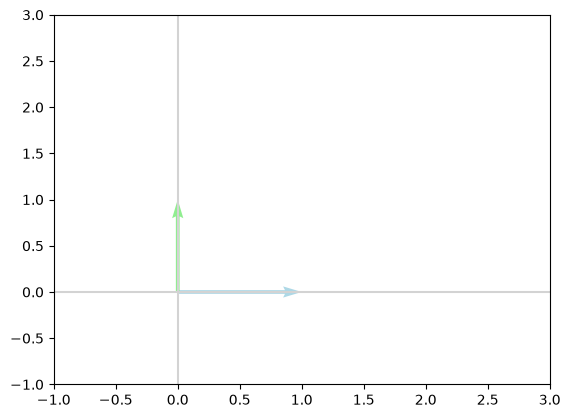

In [101]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1)],
            ['lightblue', 'lightgreen'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

Let's start by applying the matrix N to B, recalling from earlier that N is singular:

In [102]:
N= n.T

In [103]:
np.linalg.det(N)

np.float32(0.0)

In [104]:
NB = np.dot(N, B)
NB

C:\Users\Diwas\AppData\Local\Temp\ipykernel_10352\2361209457.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  NB = np.dot(N, B)


array([[-4.,  1.],
       [-8.,  2.]])

[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]
[-4. -8.]
[ 0.  0. -4. -8.]
[1. 2.]
[0. 0. 1. 2.]


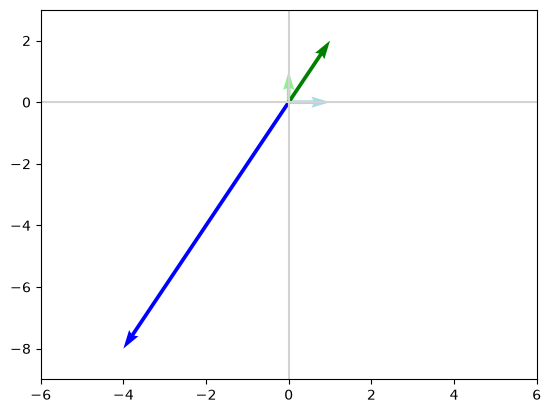

In [105]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(NB, 0), vectorfy(NB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-6, 6)
_ = plt.ylim(-9, 3)

In [106]:
lambdas, V = np.linalg.eig(N)
lambdas = lambdas.real.astype(float)
V 

tensor([[-0.4472+0.j, -0.2425+0.j],
        [-0.8944+0.j, -0.9701+0.j]])

If any one of a matrix's eigenvalues is zero, then the product of the eigenvalues must be zero and the determinant must also be zero.

In [107]:
I

array([[1, 0],
       [0, 1]])

In [108]:
np.linalg.det(I)

np.float64(1.0)

In [109]:
IB = np.dot(I, B)
IB

array([[1, 0],
       [0, 1]])

[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]
[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]


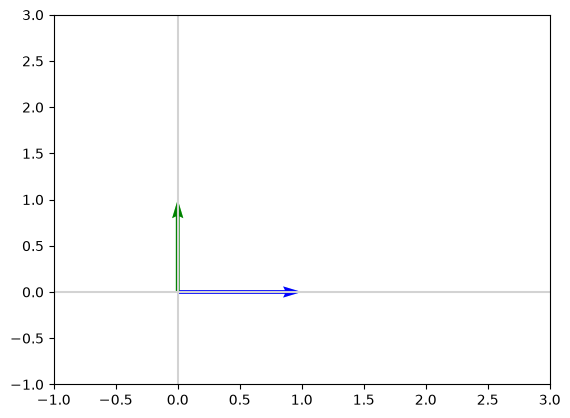

In [110]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(IB, 0), vectorfy(IB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [111]:
lambdas, V = np.linalg.eig(I)
lambdas

array([1.+0.j, 1.+0.j])

All right, so applying an identity matrix isn't the most exciting operation in the world. Let's now apply this matrix J which is more interesting:

In [112]:
J = np.array([[-0.5, 0], [0, 2]])
J

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

In [113]:
np.linalg.det(J)

np.float64(-1.0)

In [114]:
np.abs(np.linalg.det(J))

np.float64(1.0)

In [115]:
JB = np.dot(J, B)
JB

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]
[-0.5  0. ]
[ 0.   0.  -0.5  0. ]
[0. 2.]
[0. 0. 0. 2.]


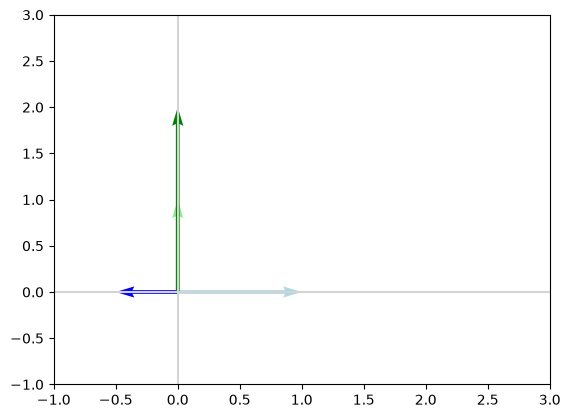

In [116]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(JB, 0), vectorfy(JB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [117]:
lambdas, V = np.linalg.eig(J)
lambdas

array([-0.5+0.j,  2. +0.j])

Finally, let's apply the matrix D, which scales vectors by doubling along both the x and y axes:

In [118]:
D = I*2
D

array([[2, 0],
       [0, 2]])

In [119]:
np.linalg.det(D)

np.float64(4.0)

In [120]:
DB = np.dot(D,B)
DB

array([[2, 0],
       [0, 2]])

[1 0]
[0 0 1 0]
[0 1]
[0 0 0 1]
[2 0]
[0 0 2 0]
[0 2]
[0 0 0 2]


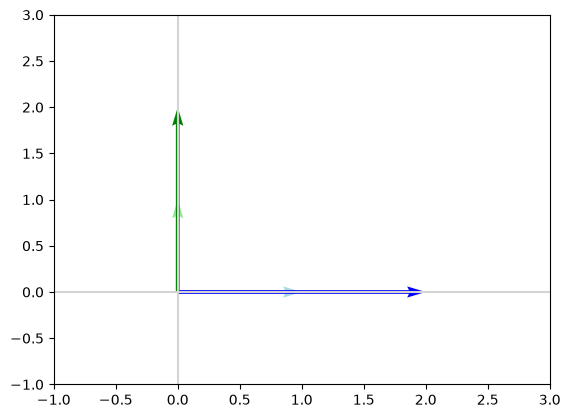

In [121]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(DB, 0), vectorfy(DB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [122]:
lambdas, V = np.linalg.eig(D)
lambdas.real.astype(float)

array([2., 2.])


## Eigendecomposition

The **eigendecomposition** of some matrix $A$ is

$$A = V \Lambda V^{-1}$$

Where:

* As in examples above, $V$ is the concatenation of all the eigenvectors of $A$
* $\Lambda$ (upper-case $\lambda$) is the diagonal matrix $\text{diag}(\lambda)$. Note that the convention is to arrange the lambda values in descending order; as a result, the first eigenvalue (and its associated eigenvector) may be a primary characteristic of the matrix $A$.

In [123]:
A = np.array([[4,2],
             [-5,-3]])
A

array([[ 4,  2],
       [-5, -3]])

In [124]:
lambdas,V = np.linalg.eig(A)

In [125]:
V

array([[ 0.70710678+0.j, -0.37139068+0.j],
       [-0.70710678+0.j,  0.92847669+0.j]])

In [126]:
Vinv = np.linalg.inv(V)
Vinv.real.astype(float)

array([[2.3570226 , 0.94280904],
       [1.79505494, 1.79505494]])

In [127]:
Lambda = np.diag(lambdas)
Lambda.real.astype(float)

array([[ 2.,  0.],
       [ 0., -1.]])

confirms $$A = V \Lambda V^{-1}$$

In [128]:
np.dot(V, np.dot(Lambda, Vinv)).real.astype(float) # which is equal to A

array([[ 4.,  2.],
       [-5., -3.]])

Eigendecomposition is not possible with all matrices. And in some cases where it is possible, the eigendecomposition involves complex numbers instead of straightforward real numbers.

In machine learning, however, we are typically working with real symmetric matrices, which can be conveniently and efficiently decomposed into real-only eigenvectors and real-only eigenvalues. If $A$ is a real symmetric matrix then...

$$A = Q \Lambda Q^T$$

...where $Q$ is analogous to $V$ from the previous equation except that it's special because it's an orthogonal matrix.

In [129]:
A = np.array([[2, 1], [1, 2]])
A

array([[2, 1],
       [1, 2]])

In [130]:
lambdas, Q = np.linalg.eig(A)

In [131]:
lambdas = lambdas.real.astype(float)
lambdas

array([3., 1.])

In [132]:
Lambda = np.diag(lambdas)
Lambda

array([[3., 0.],
       [0., 1.]])

In [133]:
Q

array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]])

Let's confirm $A = Q\Lambda Q^T$:

In [134]:
np.dot(Q, np.dot(Lambda, Q.T)).real.astype(float) # which is Q times (lambda diagonal times Q transposed)

array([[2., 1.],
       [1., 2.]])

(As a quick aside, we can demonstrate that $Q$ is an orthogonal matrix because $Q^TQ = QQ^T = I$.)

In [135]:
np.dot(Q.T, Q)

array([[1.00000000e+00+0.j, 2.23711432e-17+0.j],
       [2.23711432e-17+0.j, 1.00000000e+00+0.j]])

In [136]:
np.dot(Q.T, Q)

array([[1.00000000e+00+0.j, 2.23711432e-17+0.j],
       [2.23711432e-17+0.j, 1.00000000e+00+0.j]])

**Exercises:**

1. Use PyTorch to decompose the matrix $P$ (below) into its components $V$, $\Lambda$, and $V^{-1}$. Confirm that $P = V\Lambda V^{-1}$.
2. Use PyTorch to decompose the symmetric matrix $S$ (below) into its components $Q$, $\Lambda$, and $Q^T$. Confirm that $S = Q\Lambda Q^T$.

Question 1 solution

In [137]:
P = torch.tensor([[25, 2, -5], [3, -2, 1], [5, 7, 4.]])
P

tensor([[25.,  2., -5.],
        [ 3., -2.,  1.],
        [ 5.,  7.,  4.]])

In [138]:
S = torch.tensor([[25, 2, -5], [2, -2, 1], [-5, 1, 4.]])
S

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])

In [139]:
lambdas, V = torch.linalg.eig(P)
lambdas=lambdas.float()
lambdas

tensor([23.7644,  6.6684, -3.4328])

In [140]:
V = V.float()
V

tensor([[ 0.9511, -0.2386,  0.1626],
        [ 0.1218, -0.1924, -0.7705],
        [ 0.2837, -0.9519,  0.6163]])

In [141]:
Vinv = torch.linalg.inv(V)
Vinv

tensor([[ 1.1356,  0.0102, -0.2868],
        [ 0.3914, -0.7198, -1.0032],
        [ 0.0817, -1.1164,  0.2052]])

In [142]:
Lambda = torch.diag(lambdas)
Lambda

tensor([[23.7644,  0.0000,  0.0000],
        [ 0.0000,  6.6684,  0.0000],
        [ 0.0000,  0.0000, -3.4328]])

In [143]:
torch.matmul(V, torch.matmul(Lambda, Vinv))

tensor([[25.0000,  2.0000, -5.0000],
        [ 3.0000, -2.0000,  1.0000],
        [ 5.0000,  7.0000,  4.0000]])

which is equal to $P = V\Lambda V^{-1}$.

In [144]:
P 

tensor([[25.,  2., -5.],
        [ 3., -2.,  1.],
        [ 5.,  7.,  4.]])

Question 2 solution

In [145]:
S

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])

In [146]:
lambdas, Q = torch.linalg.eigh(S)
Q.float()

tensor([[-0.1132, -0.1943, -0.9744],
        [ 0.9651, -0.2548, -0.0614],
        [-0.2363, -0.9473,  0.2163]])

In [147]:
QT = Q.T.float()
QT

tensor([[-0.1132,  0.9651, -0.2363],
        [-0.1943, -0.2548, -0.9473],
        [-0.9744, -0.0614,  0.2163]])

In [148]:
Lambda = torch.diag(lambdas).float()
Lambda

tensor([[-2.4796,  0.0000,  0.0000],
        [ 0.0000,  3.2435,  0.0000],
        [ 0.0000,  0.0000, 26.2361]])

In [149]:
torch.matmul(Q, torch.matmul(Lambda, QT))

tensor([[25.0000,  2.0000, -5.0000],
        [ 2.0000, -2.0000,  1.0000],
        [-5.0000,  1.0000,  4.0000]])

In [150]:
S # which confirms question number 2

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])

# Segment 3: Matrix Operations for ML

## Singular Value Decomposition (SVD)

As on slides, SVD of matrix $A$ is:

$A = UDV^T$

Where:

* $U$ is an orthogonal $m \times m$ matrix; its columns are the **left-singular vectors** of $A$.
* $V$ is an orthogonal $n \times n$ matrix; its columns are the **right-singular vectors** of $A$.
* $D$ is a diagonal $m \times n$ matrix; elements along its diagonal are the **singular values** of $A$.

In [151]:
A = np.array([[-1,2],
             [3,2],
             [5,7]])
A

array([[-1,  2],
       [ 3,  2],
       [ 5,  7]])

In [152]:
U,d,VT = np.linalg.svd(A)

In [153]:
U

array([[ 0.10655106, -0.85637177, -0.50524673],
       [ 0.3660941 ,  0.50623164, -0.78083586],
       [ 0.92445767, -0.10176896,  0.36745217]])

In [154]:
d

array([9.30169873, 2.34059839])

In [155]:
np.diag(d)

array([[9.30169873, 0.        ],
       [0.        , 2.34059839]])

$D$ must have the same dimensions as $A$ for $UDV^T$ matrix multiplication to be possible:

In [161]:
D = np.concatenate((np.diag(d), [[0, 0]]), axis=0)
D

array([[9.30169873, 0.        ],
       [0.        , 2.34059839],
       [0.        , 0.        ]])

In [162]:
np.dot(U, np.dot(D, VT))

array([[-1.,  2.],
       [ 3.,  2.],
       [ 5.,  7.]])

SVD and eigendecomposition are closely related to each other:

* Left-singular vectors of $A$ = eigenvectors of $AA^T$.
* Right-singular vectors of $A$ = eigenvectors of $A^TA$.
* Non-zero singular values of $A$ = square roots of eigenvalues of $AA^T$ = square roots of eigenvalues of $A^TA$

**Exercise:** Using the matrix `P` from the preceding PyTorch exercises, demonstrate that these three SVD-eigendecomposition equations are true.

# Image Compression via SVD

The section features code adapted from [Frank Cleary's](https://gist.github.com/frankcleary/4d2bd178708503b556b0?utm_source=gemini).

In [167]:
import urllib.request

url = 'https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg'
urllib.request.urlretrieve(url, 'oboe-with-book.jpg')

('oboe-with-book.jpg', <http.client.HTTPMessage at 0x22b6b58f920>)

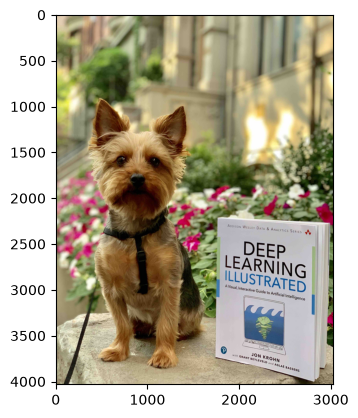

In [171]:
img = Image.open('oboe-with-book.jpg')
_ = plt.imshow(img)

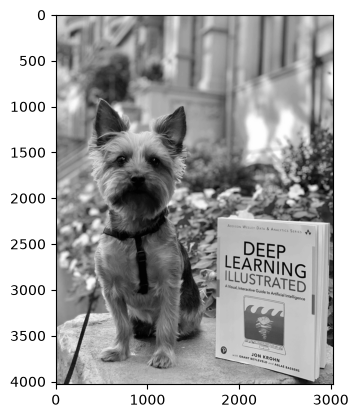

In [173]:
imggray = img.convert("LA")
imggray = plt.imshow(imggray)

Convert data into numpy matrix, which doesn't impact image data:

C:\Users\Diwas\AppData\Local\Temp\ipykernel_10352\851154232.py:9: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  imgmat = np.array(list(imggray.getdata()), dtype=float)
C:\Users\Diwas\AppData\Local\Temp\ipykernel_10352\851154232.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  imgmat.shape = (imggray.size[1], imggray.size[0])


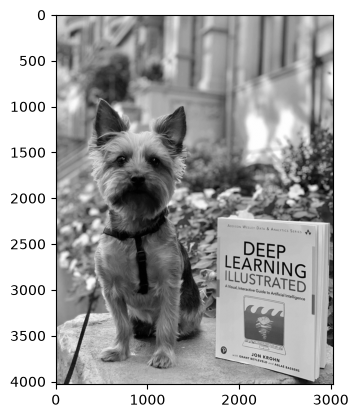

In [176]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image using PIL (Pillow) and convert it to grayscale ('L')
imggray = Image.open('oboe-with-book.jpg').convert('L')

# 2. Extract pixel data into a NumPy array
imgmat = np.array(list(imggray.getdata()), dtype=float)

# 3. Reshape and render
imgmat.shape = (imggray.size[1], imggray.size[0])
_ = plt.imshow(imgmat, cmap='gray')

Calculate SVD of the image:

In [178]:
U, sigma, V = np.linalg.svd(imgmat)

As eigenvalues are arranged in descending order in diag($\lambda$) so too are singular values, by convention, arranged in descending order in $D$ (or, in this code, diag($\sigma$)). Thus, the first left-singular vector of $U$ and first right-singular vector of $V$ may represent the most prominent feature of the image: